In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('WDISeries.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1516 entries, 0 to 1515
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Series Code                          1516 non-null   object 
 1   Topic                                1516 non-null   object 
 2   Indicator Name                       1516 non-null   object 
 3   Short definition                     1499 non-null   object 
 4   Long definition                      1499 non-null   object 
 5   Unit of measure                      1193 non-null   object 
 6   Periodicity                          1474 non-null   object 
 7   Base Period                          0 non-null      float64
 8   Other notes                          344 non-null    object 
 9   Aggregation method                   1103 non-null   object 
 10  Limitations and exceptions           916 non-null    object 
 11  Notes from original source    

In [4]:
df.head()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type
0,AG.CON.FERT.PT.ZS,Environment: Agricultural production,Fertilizer consumption (% of fertilizer produc...,Fertilizer consumption measures the quantity o...,Fertilizer consumption measures the quantity o...,% (ratio),Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Fertilizer consumption measures t...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
1,AG.CON.FERT.ZS,Environment: Agricultural production,Fertilizer consumption (kilograms per hectare ...,Fertilizer consumption measures the quantity o...,Fertilizer consumption measures the quantity o...,kg per hectare of arable land,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Fertilizer consumption measures t...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
2,AG.LND.AGRI.K2,Environment: Land use,Agricultural land (sq. km),Agricultural land refers to the share of land ...,Agricultural land refers to the share of land ...,square kilometers (sq. km),Annual,NaN,Areas of former states are included in the suc...,Sum,The data are collected by the Food and Agricul...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Agricultural land constitutes onl...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
3,AG.LND.AGRI.ZS,Environment: Land use,Agricultural land (% of land area),Agricultural land refers to the share of land ...,Agricultural land refers to the share of land ...,% (share) of land area,Annual,NaN,Areas of former states are included in the suc...,Weighted average,The data are collected by the Food and Agricul...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Agriculture is still a major sect...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
4,AG.LND.ARBL.HA,Environment: Land use,Arable land (hectares),Arable land (in hectares) includes land define...,Arable land (in hectares) includes land define...,hectares,Annual,NaN,Areas of former states are included in the suc...,NaN,The Food and Agriculture Organization (FAO) tr...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Temporary fallow land refers to l...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0


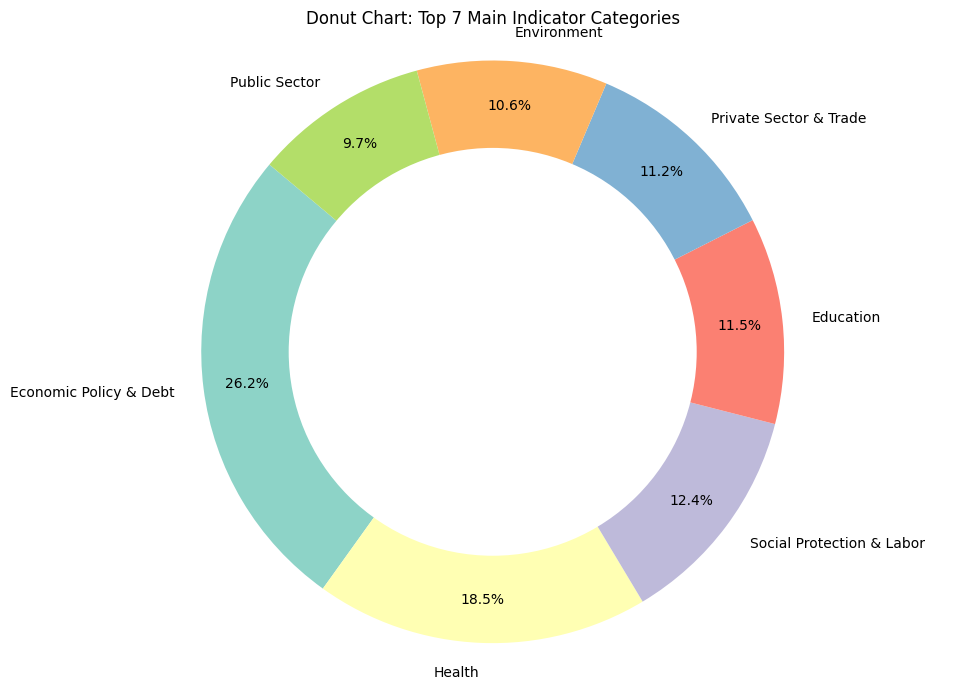

In [5]:
df['Main Topic'] = df['Topic'].fillna('Unknown').apply(lambda x: x.split(':')[0])
top_main_topics = df['Main Topic'].value_counts().head(7)

# Create the donut chart
fig, ax = plt.subplots(figsize=(10, 7))

# Pie chart part
wedges, texts, autotexts = ax.pie(
    top_main_topics, 
    labels=top_main_topics.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Set3.colors,
    pctdistance=0.85
)

# Draw a white circle in the middle to make it a donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')  
plt.title('Donut Chart: Top 7 Main Indicator Categories')
plt.tight_layout()

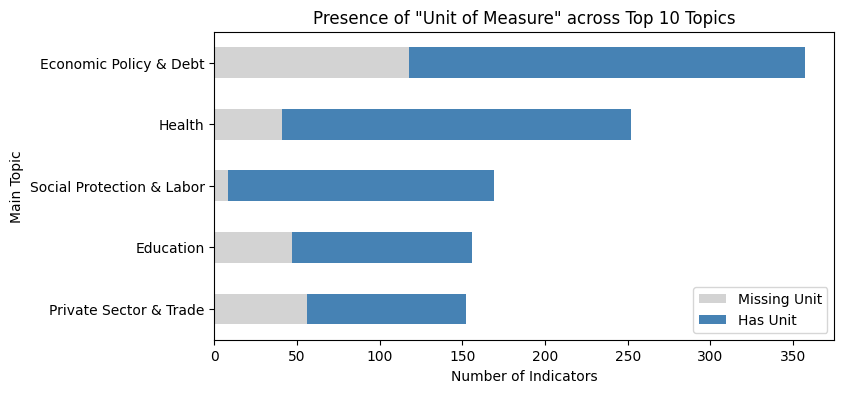

In [6]:
df['Main Topic'] = df['Topic'].fillna('Unknown').apply(lambda x: str(x).split(':')[0])

# Top 10 topics by indicator count
top_5_topics = df['Main Topic'].value_counts().nlargest(5).index

# Filter data for these top 10 topics
df_top = df[df['Main Topic'].isin(top_5_topics)].copy()

# Check if 'Unit of measure' is provided (non-null)
df_top['Has Unit'] = df_top['Unit of measure'].notnull()

# Group by Topic and 'Has Unit' status
stacked_data = df_top.groupby(['Main Topic', 'Has Unit']).size().unstack(fill_value=0)

# Sort by total count for a better visual
stacked_data['Total'] = stacked_data.sum(axis=1)
stacked_data = stacked_data.sort_values('Total', ascending=True)
plot_data = stacked_data.drop(columns='Total')

# Plotting
plot_data.plot(kind='barh', stacked=True, color=['lightgrey', 'steelblue'], figsize=(8, 4))

plt.title('Presence of "Unit of Measure" across Top 10 Topics')
plt.xlabel('Number of Indicators')
plt.ylabel('Main Topic')
plt.legend(['Missing Unit', 'Has Unit'], loc='lower right')


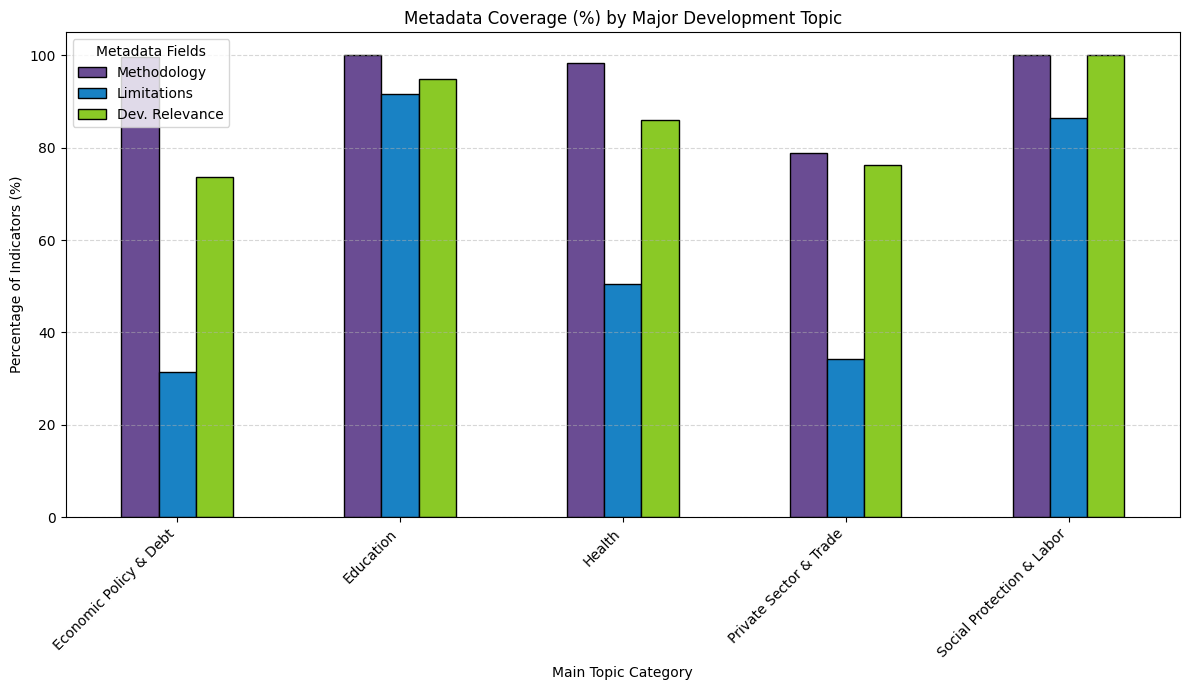

In [7]:
df['Main Topic'] = df['Topic'].fillna('Unknown').apply(lambda x: str(x).split(':')[0])

# Identify the top 5 Main Topics
top_5_topics = df['Main Topic'].value_counts().nlargest(5).index
filtered = df[df['Main Topic'].isin(top_5_topics)].copy()

# Create presence flags for advanced metadata fields
filtered['Has Methodology'] = filtered['Statistical concept and methodology'].notnull()
filtered['Has Limitations'] = filtered['Limitations and exceptions'].notnull()
filtered['Has Relevance'] = filtered['Development relevance'].notnull()

# Calculate the percentage of indicators in each topic that have these fields populated
summary = filtered.groupby('Main Topic')[['Has Methodology', 'Has Limitations', 'Has Relevance']].mean() * 100

# Plotting as a grouped bar chart
summary.plot(kind='bar', figsize=(12, 7), color=['#6a4c93', '#1982c4', '#8ac926'], edgecolor='black')

plt.title('Metadata Coverage (%) by Major Development Topic')
plt.ylabel('Percentage of Indicators (%)')
plt.xlabel('Main Topic Category')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metadata Fields', labels=['Methodology', 'Limitations', 'Dev. Relevance'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

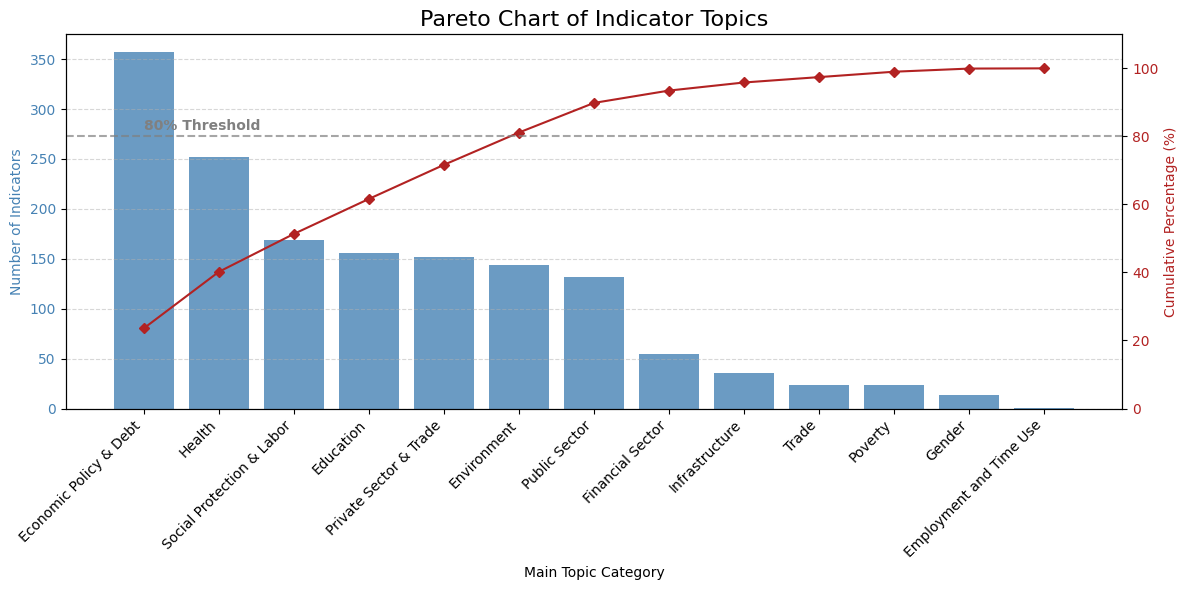

In [9]:
df['Main Topic'] = df['Topic'].fillna('Unknown').apply(lambda x: str(x).split(':')[0])

# 1. Prepare data for a Pareto Chart
topic_counts = df['Main Topic'].value_counts().sort_values(ascending=False)
df_pareto = pd.DataFrame({'Counts': topic_counts})
df_pareto['Cum_Percentage'] = df_pareto['Counts'].cumsum() / df_pareto['Counts'].sum() * 100

# 2. Plotting the Pareto Chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for counts
ax1.bar(df_pareto.index, df_pareto['Counts'], color='steelblue', alpha=0.8)
ax1.set_xlabel('Main Topic Category')
ax1.set_ylabel('Number of Indicators', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
plt.xticks(rotation=45, ha='right')

# Line chart for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(df_pareto.index, df_pareto['Cum_Percentage'], color='firebrick', marker='D', ms=5, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage (%)', color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')
ax2.set_ylim(0, 110)

# Add title and grid
plt.title('Pareto Chart of Indicator Topics', fontsize=16)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Add a 80% line for Pareto analysis
ax2.axhline(80, color='grey', linestyle='--', alpha=0.7)
ax2.text(0, 82, '80% Threshold', color='grey', fontweight='bold')

plt.tight_layout()